In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **LOAD DATA**

In [4]:
df = pd.read_csv('../datasets/paysim-dataset.csv')

Deskriptif Statistik

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.shape

(6362620, 11)

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Tipe Data:

In [8]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Cek Missing Value

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

In [11]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


cek duplikat

In [12]:
df.duplicated().sum()

np.int64(0)

Deep search manual cari duplicate dan anomali lain

In [13]:
# No self-transaction, no duplikat baris(cek manual), no ID collision C/M 

# Ga ada transaksi dari pengirim ke penerima yang sama (self-transaction)
self_transaction = df[df['nameOrig'] == df['nameDest']]
print(f"Self Transaction Count: {len(self_transaction)}")

# Ga ada duplikat baris (cek manual) di step + type + nameOrig + nameDest + oldbalanceOrg
dup_cols = ['step', 'type', 'nameOrig', 'nameDest', 'oldbalanceOrg']
duplicates = df[df.duplicated(subset=dup_cols, keep=False)]
print(f"Row Duplicate Count: {len(duplicates)}")

# Cek distribusi karakter pertama dari nameOrig dan nameDest
print(df['nameOrig'].str[0].value_counts())
print(df['nameDest'].str[0].value_counts())


Self Transaction Count: 0
Row Duplicate Count: 0
nameOrig
C    6362620
Name: count, dtype: int64
nameDest
C    4211125
M    2151495
Name: count, dtype: int64


Cek negative values

In [ ]:
# no negative values
neg_check = df[(df['amount']<0) | (df['oldbalanceOrg']<0) | 
(df['newbalanceOrig']<0) | (df['oldbalanceDest']<0) | 
(df['newbalanceDest']<0)]
print(len(neg_check))

0


Cek anomali step unique

In [49]:
# Step kontinu 1-743, gap di 744 cuma karena ujung periode, bukan data hilang

missing_steps = set(range(1,745)) - set(df['step'].unique())
print(f"Missing Step: {missing_steps}")

Missing Step: {744}


Analisis kenapa balance di payment dan sebagian Cash_Out 0

In [16]:
# Balance 0→0 massal di PAYMENT/sebagian CASH_OUT — merchant gak punya balance tercatat
# ini buang semua yang stuck di angka kecil/0, dan cuma sisain yang stuck di angka besar (di atas 1000). 
# Logikanya: kalau balance kamu 5 juta terus abis transfer 5 juta tetep tercatat 5 juta, itu aneh 
# beda sama kalau balance kamu 0 dan abis bayar tetep 0 (itu mah emang gak ada uangnya dari awal).

relevant_types = df[df['type'].isin(['PAYMENT', 'TRANSFER', 'CASH_OUT'])]
stuck_balance = relevant_types[relevant_types['oldbalanceOrg'] == relevant_types['newbalanceOrig']]
print(stuck_balance['type'].value_counts())
print(stuck_balance[['oldbalanceOrg', 'newbalanceOrig']].describe())

# → Hasil: 2.082.846 baris, median 0→0, breakdown CASH_OUT/PAYMENT/TRANSFER
# Dikonfirmasi lebih lanjut dengan PAYMENT sum check: Hasil: 2.151.495, match persis sama jumlah nameDest prefix M

print((df['type'] == 'PAYMENT').sum())

type
CASH_OUT    1025801
PAYMENT      774245
TRANSFER     282800
Name: count, dtype: int64
       oldbalanceOrg  newbalanceOrig
count   2.082846e+06    2.082846e+06
mean    6.044625e+01    6.044625e+01
std     2.863227e+04    2.863227e+04
min     0.000000e+00    0.000000e+00
25%     0.000000e+00    0.000000e+00
50%     0.000000e+00    0.000000e+00
75%     0.000000e+00    0.000000e+00
max     1.958504e+07    1.958504e+07
2151495


Tentuin anomali dari Anomali formula balance (newbalance ≠ oldbalance ± amount) di TRANSFER/CASH_OUT 

In [17]:
# Anomali formula matematis balance (66-80% baris) — by-design, bukan corrupt
# Hasil: 79,81% origin, 65,83% dest

df['expected_new_orig'] = df['oldbalanceOrg'] - df['amount']
df['diff_orig'] = df['newbalanceOrig'] - df['expected_new_orig']
df['expected_new_dest'] = df['oldbalanceDest'] + df['amount']
df['diff_dest'] = df['newbalanceDest'] - df['expected_new_dest']

anomali_orig = df[df['diff_orig'].abs() > 0.01]
anomali_dest = df[df['diff_dest'].abs() > 0.01]

print(f"Anomali balance origin: {len(anomali_orig)} ({len(anomali_orig)/len(df)*100:.2f}%)")
print(f"Anomali balance dest: {len(anomali_dest)} ({len(anomali_dest)/len(df)*100:.2f}%)")

# Hasil: CASH_OUT 545 + TRANSFER 4.095 = 4.640 dari total 8.213 fraud (~56%)
# dari semua 8.213 kasus fraud di seluruh dataset, 4.640 di antaranya (56%) punya ciri "balance penerima gak sesuai formula matematis". 
# Artinya kalau kamu pakai kondisi anomali_dest sebagai filter/fitur, dia bakal "nangkep" lebih dari separuh kasus fraud yang ada

print(pd.crosstab(anomali_dest['type'], anomali_dest['isFraud']))

Anomali balance origin: 5077691 (79.81%)
Anomali balance dest: 4188647 (65.83%)
isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT   506881   545
DEBIT        9631     0
PAYMENT   2151495     0
TRANSFER   116716  4095


Cek Balance penerima justru berkurang padahal dia menerima uang dan Balance pengirim justru bertambah padahal dia mengirim uang

In [18]:
# Sinyal lemah — H4 & H5
# H5 (orig naik) exclude CASH_IN
# Hasil: 2 baris, CASH_OUT, non-fraud

orig_increased = df[(df['newbalanceOrig'] > df['oldbalanceOrg']) & (df['amount'] > 0)]
orig_increased_no_cashin = orig_increased[orig_increased['type'] != 'CASH_IN']
print(len(orig_increased_no_cashin))
print(orig_increased_no_cashin['type'].value_counts())
print(orig_increased_no_cashin['isFraud'].value_counts())

print("================================")

# H4 (dest turun) exclude CASH_IN
# Hasil: 44.385 baris, tapi cuma 27 fraud (0,06%)

dest_decreased = df[(df['newbalanceDest'] < df['oldbalanceDest']) & (df['amount'] > 0)]
dest_decreased_no_cashin = dest_decreased[dest_decreased['type'] != 'CASH_IN']
print(len(dest_decreased_no_cashin))
print(dest_decreased_no_cashin['type'].value_counts())
print(dest_decreased_no_cashin['isFraud'].value_counts())

2
type
CASH_OUT    2
Name: count, dtype: int64
isFraud
0    2
Name: count, dtype: int64
44385
type
CASH_OUT    39020
TRANSFER     3931
DEBIT        1434
Name: count, dtype: int64
isFraud
0    44358
1       27
Name: count, dtype: int64


Analisis fraud berdasarkan jenis transaksi (TRANSFER, CASH_OUT, dll)

In [19]:
df.groupby("type")["isFraud"].agg(["sum", "count", "mean"])

,sum,count,mean
type,,,
CASH_IN,0,1399284,0.000000
CASH_OUT,4116,2237500,0.001840
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000
TRANSFER,4097,532909,0.007688


semua transaksi yang amount = 0

In [20]:
df[df["amount"] == 0]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,expected_new_orig,diff_orig,expected_new_dest,diff_dest
2736447,212,CASH_OUT,0.0,C1510987794,0.0,0.0,C1696624817,0.00,0.00,1,0,0.0,0.0,0.00,0.0
3247298,250,CASH_OUT,0.0,C521393327,0.0,0.0,C480398193,0.00,0.00,1,0,0.0,0.0,0.00,0.0
3760289,279,CASH_OUT,0.0,C539112012,0.0,0.0,C1106468520,538547.63,538547.63,1,0,0.0,0.0,538547.63,0.0
5563714,387,CASH_OUT,0.0,C1294472700,0.0,0.0,C1325541393,7970766.57,7970766.57,1,0,0.0,0.0,7970766.57,0.0
5996408,425,CASH_OUT,0.0,C832555372,0.0,0.0,C1462759334,76759.90,76759.90,1,0,0.0,0.0,76759.90,0.0
5996410,425,CASH_OUT,0.0,C69493310,0.0,0.0,C719711728,2921531.34,2921531.34,1,0,0.0,0.0,2921531.34,0.0
6168500,554,CASH_OUT,0.0,C10965156,0.0,0.0,C1493336195,230289.66,230289.66,1,0,0.0,0.0,230289.66,0.0
6205440,586,CASH_OUT,0.0,C1303719003,0.0,0.0,C900608348,1328472.86,1328472.86,1,0,0.0,0.0,1328472.86,0.0
6266414,617,CASH_OUT,0.0,C1971175979,0.0,0.0,C1352345416,0.00,0.00,1,0,0.0,0.0,0.00,0.0
6281483,646,CASH_OUT,0.0,C2060908932,0.0,0.0,C1587892888,0.00,0.00,1,0,0.0,0.0,0.00,0.0


cek jumlah nilai transaksi yang negatif per kolom

In [21]:
cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
        "oldbalanceDest", "newbalanceDest"]

print((df[cols] < 0).sum())

amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64


In [22]:
# Origin (berdasarkan nameOrig)
orig_err_C = (df[df["nameOrig"].str.startswith("C")]
              ["oldbalanceOrg"].sub(df["amount"])
              .sub(df["newbalanceOrig"])
              .abs().gt(0.01).sum())

orig_err_M = (df[df["nameOrig"].str.startswith("M")]
              ["oldbalanceOrg"].sub(df["amount"])
              .sub(df["newbalanceOrig"])
              .abs().gt(0.01).sum())


# Destination (berdasarkan nameDest)
dest_err_C = (df[df["nameDest"].str.startswith("C")]
              ["oldbalanceDest"].add(df["amount"])
              .sub(df["newbalanceDest"])
              .abs().gt(0.01).sum())

dest_err_M = (df[df["nameDest"].str.startswith("M")]
              ["oldbalanceDest"].add(df["amount"])
              .sub(df["newbalanceDest"])
              .abs().gt(0.01).sum())


print("Origin error (C):", orig_err_C)
print("Origin error (M):", orig_err_M)
print("Destination error (C):", dest_err_C)
print("Destination error (M):", dest_err_M)

Origin error (C): 5077691
Origin error (M): 0
Destination error (C): 2037152
Destination error (M): 2151495


In [23]:
print(df[df['nameDest'].str.startswith('M')]['oldbalanceDest'])

0          0.0
1          0.0
4          0.0
5          0.0
6          0.0
          ... 
6362312    0.0
6362314    0.0
6362316    0.0
6362318    0.0
6362319    0.0
Name: oldbalanceDest, Length: 2151495, dtype: float64


In [24]:
print(df[df['nameDest'].str.startswith('M')]['isFraud'])

0          0
1          0
4          0
5          0
6          0
          ..
6362312    0
6362314    0
6362316    0
6362318    0
6362319    0
Name: isFraud, Length: 2151495, dtype: int64


In [25]:
print("Name Prefix Analysis:")
print(f"nameOrig unique prefixes : {df['nameOrig'].str[0].unique()}")
print(f"nameDest prefix counts   :")
print(df["nameDest"].str[0].value_counts())

Name Prefix Analysis:
nameOrig unique prefixes : ['C']
nameDest prefix counts   :
nameDest
C    4211125
M    2151495
Name: count, dtype: int64


Q1=13389.57, Q3=208721.48, IQR=195331.91
Upper fence (IQR)=501719.34
IQR outliers: 338078 (5.31%)
99.9th percentile=8956797.68
>99.9% count: 6363


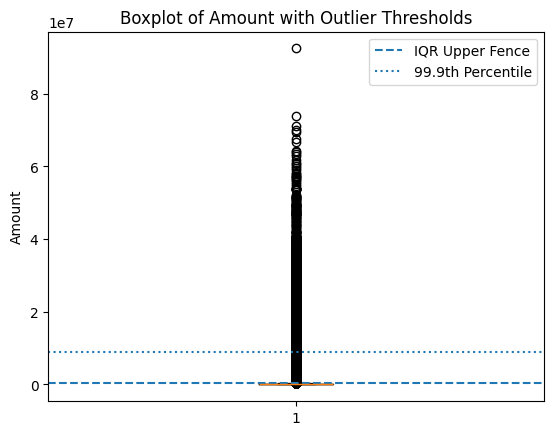

In [26]:
import matplotlib.pyplot as plt

Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

p999 = df["amount"].quantile(0.999)

iqr_outliers = (df["amount"] > upper_fence).sum()
p999_outliers = (df["amount"] > p999).sum()

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Upper fence (IQR)={upper_fence:.2f}")
print(f"IQR outliers: {iqr_outliers} ({iqr_outliers/len(df)*100:.2f}%)")
print(f"99.9th percentile={p999:.2f}")
print(f">99.9% count: {p999_outliers}")

plt.figure()
plt.boxplot(df["amount"])
plt.axhline(upper_fence, linestyle='--', label='IQR Upper Fence')
plt.axhline(p999, linestyle=':', label='99.9th Percentile')

plt.title("Boxplot of Amount with Outlier Thresholds")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [27]:
df[(df['isFlaggedFraud']==0) & (df['isFraud']==1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,expected_new_orig,diff_orig,expected_new_dest,diff_dest
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,0.0,0.0,181.00,-1.810000e+02
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,0.0,0.0,21363.00,-2.136300e+04
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0,0.0,0.0,2806.00,-2.806000e+03
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0,0.0,0.0,29008.00,-2.900800e+04
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0,0.0,0.0,20128.00,-2.012800e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,0.0,0.0,339682.13,0.000000e+00
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,0.0,0.0,6311409.28,-6.311409e+06
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,0.0,0.0,6379898.12,-1.000000e-02
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,0.0,0.0,850002.52,-8.500025e+05


##**Univariate Visualization**

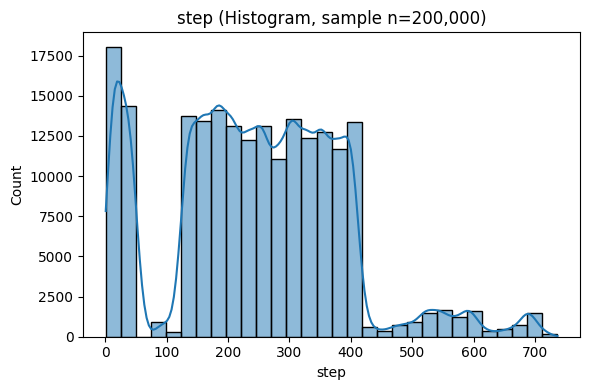

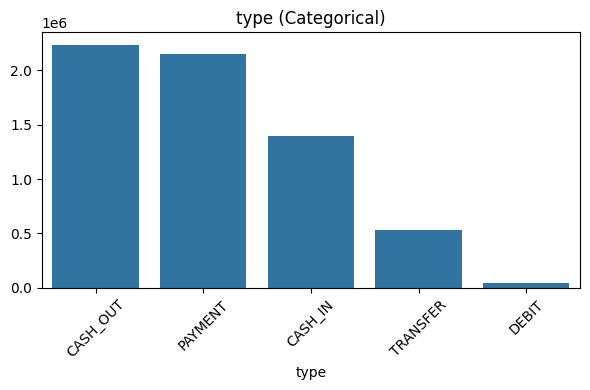

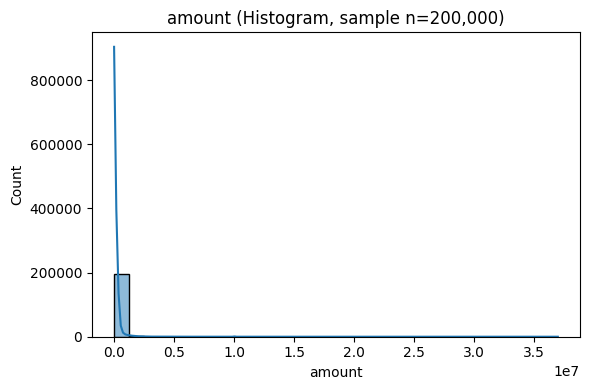

Skip 'nameOrig' (ID-like, dikecualikan dari plot)


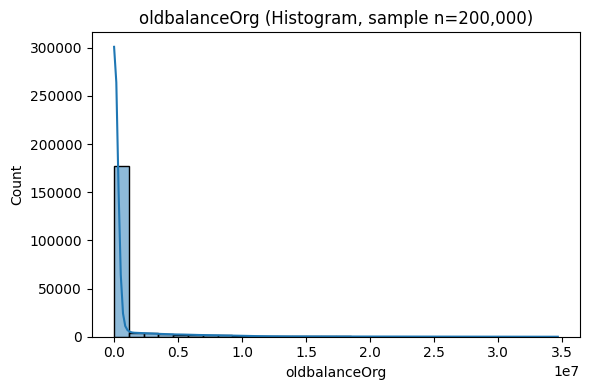

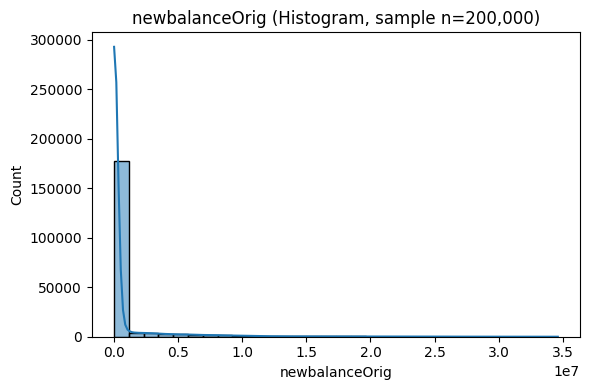

Skip 'nameDest' (ID-like, dikecualikan dari plot)


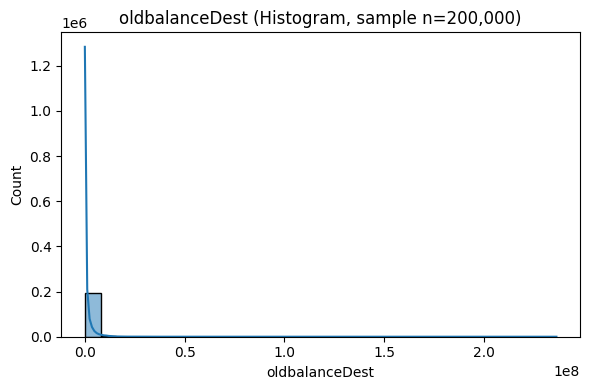

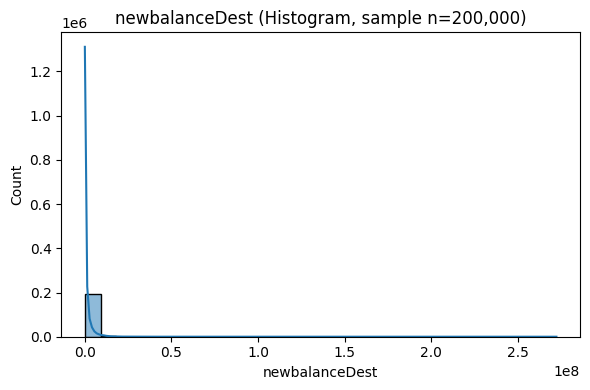

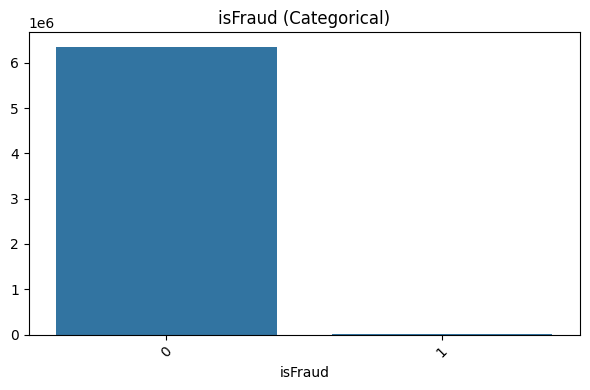

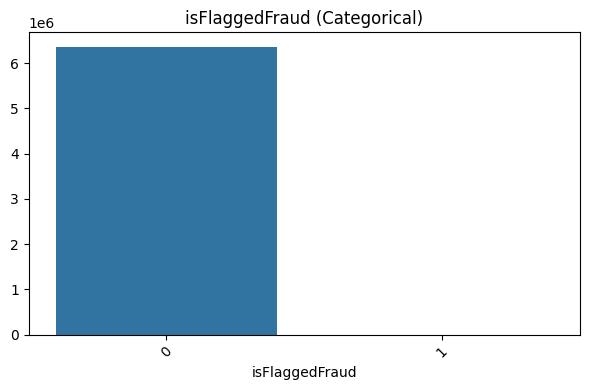

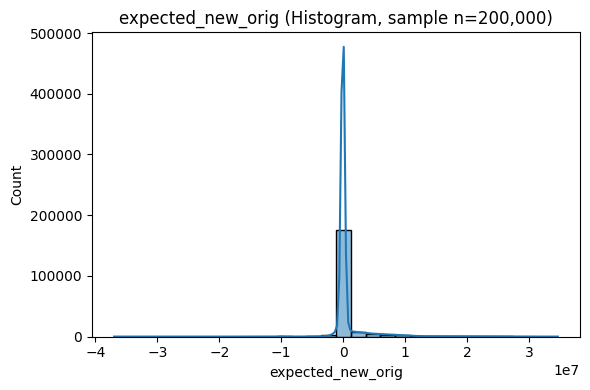

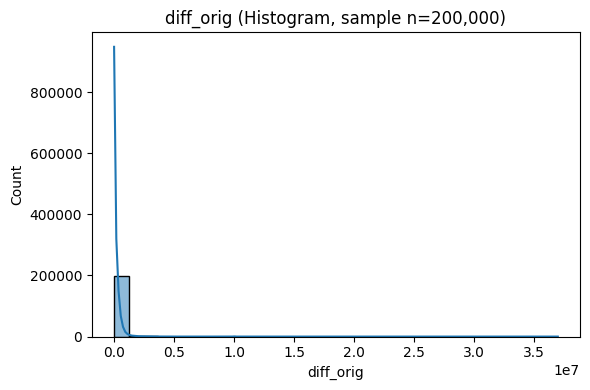

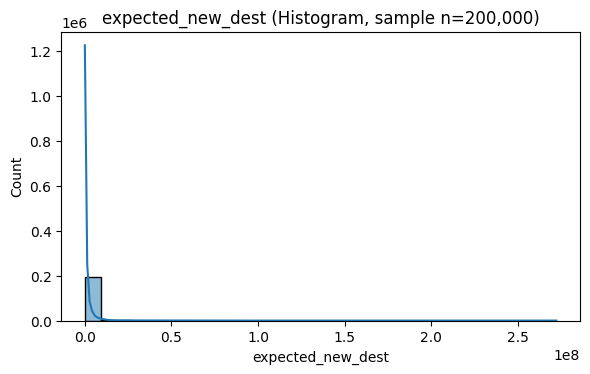

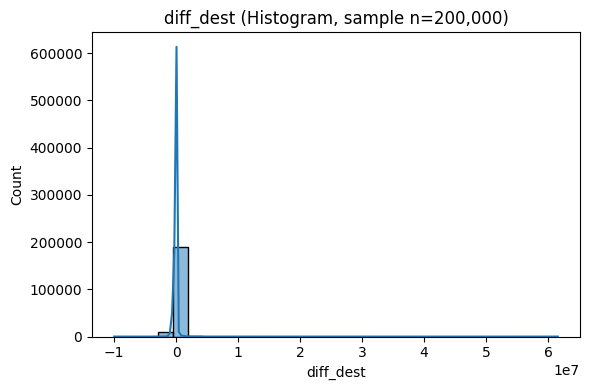

In [28]:
def plot_auto(df, sample_size=200_000, exclude_cols=None, random_state=42):
    # exclude_cols: kolom ID-like (nameOrig/nameDest) yang nunique()-nya jutaan dan
    # dtype-nya object - inilah yang bikin versi lama cell ini KeyboardInterrupt,
    # karena sns.histplot(..., kde=True) dipaksa jalan di atas teks nyaris-unik.
    exclude_cols = set(exclude_cols or [])
    plot_df = df if len(df) <= sample_size else df.sample(sample_size, random_state=random_state)

    for col in df.columns:
        if col in exclude_cols:
            print(f"Skip '{col}' (ID-like, dikecualikan dari plot)")
            continue

        unique_count = df[col].nunique()

        plt.figure(figsize=(6,4))

        # CASE 1: categorical (unique < 15)
        if unique_count < 15:
            value_counts = df[col].value_counts()

            sns.barplot(
                x=value_counts.index,
                y=value_counts.values
            )

            plt.title(f"{col} (Categorical)")
            plt.xticks(rotation=45)

        # CASE 2: numerical / many unique
        else:
            # pakai sample, bukan seluruh 6.3 juta baris - bentuk distribusinya sama
            # tapi jauh lebih cepat (cell ini sebelumnya macet kalau langsung df penuh)
            sns.histplot(plot_df[col].dropna(), bins=30, kde=True)

            plt.title(f"{col} (Histogram, sample n={len(plot_df):,})")

        plt.tight_layout()
        plt.show()

plot_auto(df, exclude_cols=["nameOrig", "nameDest"])


##**Data Cleaning**

In [29]:
cleaning_log = []

In [30]:
before = len(df)
df.drop_duplicates(inplace=True)
removed = before - len(df)
cleaning_log.append(f"Duplicates removed : {removed}")
print(f"Duplicates removed: {removed}")

Duplicates removed: 0


In [31]:
before = len(df)
df = df[df["amount"] > 0].copy()
removed = before - len(df)
cleaning_log.append(f"Zero-amount rows removed : {removed} (all were isFraud=1 CASH_OUT simulator artifacts)")
print(f"Zero-amount rows removed: {removed}")

Zero-amount rows removed: 16


In [32]:
df.drop(columns=["isFlaggedFraud"], inplace=True)
cleaning_log.append("Dropped 'isFlaggedFraud' : 0.19% recall, subset of isFraud — not predictive")
print("Dropped column: isFlaggedFraud")

Dropped column: isFlaggedFraud


In [33]:
df.drop(columns=["nameOrig"], inplace=True)
cleaning_log.append("Dropped 'nameOrig' : zero entropy (all 'C' prefix), transaction ID only")
print("Dropped column: nameOrig")

Dropped column: nameOrig


In [34]:
df.shape

(6362604, 13)

##**Feature Engineering**

In [ ]:
# origError/destError menggantikan balanceDiffOrig/balanceDiffDest yang lama, supaya
# konsisten dengan phase_1.py. balanceDiffOrig/balanceDiffDest (signed, = newbalance -
# oldbalance) nyaris selalu sama dengan -amount/+amount pada transaksi normal - jadi
# hampir redundan dengan amount itu sendiri. origError/destError (unsigned) mengukur
# SEBERAPA JAUH saldo aktual menyimpang dari yang seharusnya - rumus sama persis dengan
# EDA "Anomali formula balance" di atas - dan ini fitur paling kuat membedakan
# fraud-rate tinggi di Phase 2 & 3.

df["origError"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
).abs()

df["destError"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
).abs()


# Bersihkan kolom scratch dari EDA "Anomali formula balance" (expected_new_orig,
# diff_orig, expected_new_dest, diff_dest). Secara matematis origError = diff_orig.abs()
# dan destError = diff_dest.abs() - kalau tidak dibuang, kolom-kolom itu akan ikut
# tersimpan ke parquet final padahal isinya duplikat dari origError/destError.
df.drop(
    columns=["expected_new_orig", "diff_orig", "expected_new_dest", "diff_dest"],
    inplace=True,
    errors="ignore"
)


In [36]:
# Cell ini dihapus isinya: mask_no_activity mengecek amount==0 & balanceDiffOrig==0 &
# balanceDiffDest==0, tapi baris amount==0 sudah dibuang semua di tahap Cleaning (lihat
# komentar asli "This condition will always be False now" - sudah benar, kondisinya
# memang selalu False sekarang). balanceDiffOrig/balanceDiffDest juga sudah diganti
# origError/destError, jadi cek ini sekalian tidak relevan lagi.


Mengukur seberapa jauh saldo aktual menyimpang dari yang seharusnya (konsistensi ledger). <br>
origError untuk error pada saldo pengirim <br>
destError untuk error pada saldo penerima <br>
Nilainya 0 kalau update saldo sudah sesuai formula matematis, dan makin besar kalau makin menyimpang - lihat juga EDA "Anomali formula balance" di atas, rumusnya sama.


In [37]:
df["isDestMerchant"] = (df["nameDest"].str.startswith("M")).astype(np.int8)

In [38]:
df.drop(columns=["nameDest"], inplace=True)

Menandai apakah tujuan transaksi adalah merchant atau bukan.

Karena data sudah disimpan di isDestMerchant, jadi ID unik yang digunakan tidak dipakai lagi

In [ ]:
df["origDrainedToZero"] = ((df["oldbalanceOrg"] > 0) 
    & (df["newbalanceOrig"] == 0)).astype(np.int8)

Menandai apakah akun pengirim dikuras habis <br>
oldbalanceOrg > 0 untuk sebelumnya ada uang <br>
newbalanceOrig == 0 untuk setelah transaksi jadi nol <br>
Karena Fraud sering menguras saldo sampai habis

In [40]:
df.groupby("origDrainedToZero")["isFraud"].mean()

origDrainedToZero
0    0.000038
1    0.005269
Name: isFraud, dtype: float64

Mengelompokkan data berdasarkan origDrainedToZero (0 atau 1) dan menghitung rata-rata isFraud, 1 artinya fraud tinggi, 0 artinya fraud rendah

### **ENTROPY ANALYSIS**

In [41]:
from scipy.stats import entropy as scipy_entropy

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud', 'step']

def discrete_entropy(series):
  counts = series.value_counts(normalize=True)
  return scipy_entropy(counts)

ent_res = {}
for col in numeric_cols:
  binned = pd.cut(df[col].astype(float), bins=20)
  ent_res[col] = discrete_entropy(binned)
  print(f"{col:20s} : {ent_res[col]:.3f}")

#categorical cols
ent_res['isDestMerchant'] = discrete_entropy(df['isDestMerchant'])
print(f"isDestMerchant : {ent_res['isDestMerchant']:.3f}")
ent_res['type']= discrete_entropy(df['type'])
print(f'type: {ent_res["type"]:.3f}')

amount               : 0.017
oldbalanceOrg        : 0.419
newbalanceOrig       : 0.475
oldbalanceDest       : 0.033
newbalanceDest       : 0.038
isFraud              : 0.010
step                 : 2.486
isDestMerchant : 0.640
type: 1.308


Mengecek entropy untuk mengukur seberapa acak suatu data. Nilai entropy yang tinggi menunjukkan bahwa data variatif dan acak, sedangkan entropy rendah menggambarkan bahwa data seragam.

### **Data Transformation**

In [42]:
type_dummies = pd.get_dummies(df["type"], prefix="type", dtype=np.int8)
df = pd.concat([df.drop(columns=["type"]), type_dummies], axis=1)


Mengubah kolom type jadi beberapa kolom biner, hapus kolom lama, gabung hasil encoding

Log1p digunakan sebelum RobustScaler untuk mengurangi skewness pada fitur-fitur transaksi tanpa menghilangkan karakteristik outlier. Berbeda dengan clipping atau winsorizing yang memotong nilai ekstrem, log1p hanya mengompresi nilainya sehingga informasi penting pada transaksi fraud tetap terjaga, sementara distribusi data menjadi lebih stabil untuk proses clustering dan visualisasi

In [ ]:
from sklearn.preprocessing import RobustScaler
from joblib import dump
import os

scale_cols = [
    "amount", "oldbalanceOrg", "oldbalanceDest",
    "origError", "destError"
]

# Log1p sebelum RobustScaler untuk meredam skewness ekstrem
# (aman: seluruh kolom di scale_cols sudah dipastikan >= 0 dari EDA sebelumnya)
for col in scale_cols:
    df[col] = np.log1p(df[col])

scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
cleaning_log.append("Applied Log1p + RobustScaler : log1p tames extreme right-skew, RobustScaler then handles remaining scale/outliers.")

# Simpan scaler supaya konsisten dengan phase_1.py dan bisa dipakai ulang di phase
# berikutnya tanpa fit ulang - sebelumnya notebook ini tidak pernah menyimpan scaler
# sama sekali walaupun models/robust_scaler.pkl sudah ada di project (file itu
# dihasilkan dari phase_1.py, bukan dari notebook ini).
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
scaler_path = os.path.join(models_dir, "robust_scaler.pkl")
dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")


Scalling digunakan untuk menyamakan semua skala fitur agar tidak ada fitur yang mendominasi dan menyebabkan bias pada hasil clustering. Dengan scalling semua fitur punya pengaruh yang adil. scaling (normalisasi) fitur numerik, khususnya supaya model tidak “terganggu” oleh nilai yang sangat besar atau outlier.

### **Feature Selection**

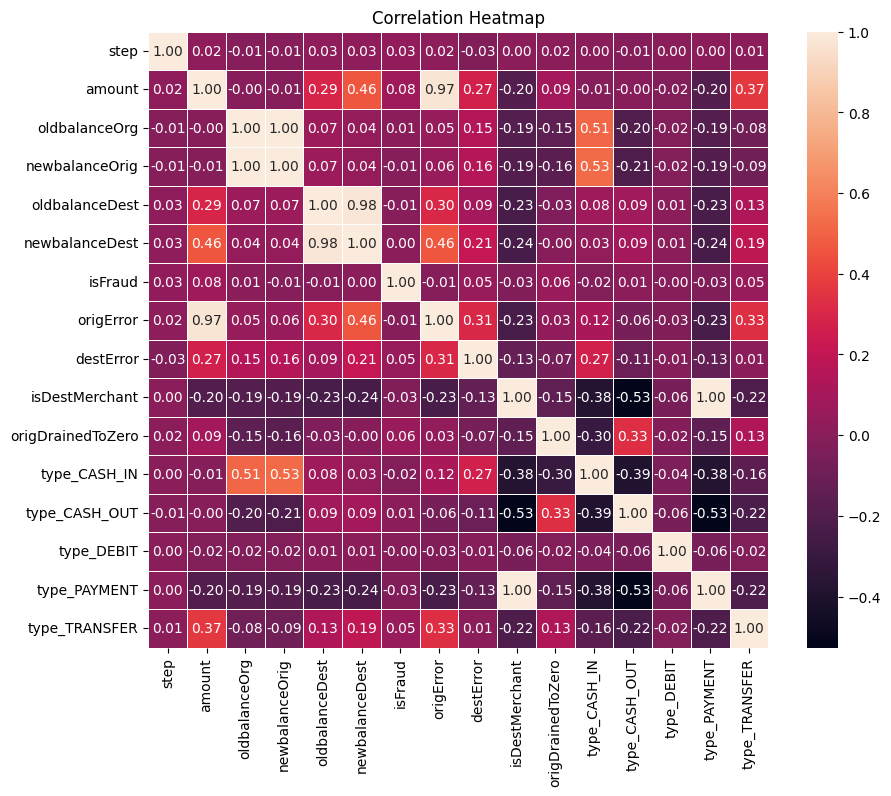

In [44]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap")
plt.show()

harusnya di heatmap masih ada beberapa yang harus di drop

In [45]:
cols_to_drop = ["newbalanceOrig", "newbalanceDest"]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
cleaning_log.append("Dropped 'newbalanceOrig' & 'newbalanceDest' : Menghindari multikolinearitas (informasinya sudah terwakili oleh origError/destError)")


Kode itu dipakai untuk menghapus fitur yang redundant agar model tidak terkena multikolinearitas.

In [46]:
df.describe()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06,6.362604e+06
mean,2.433965e+02,5.374923e-01,7.637972e+00,1.026467e+00,1.288309e-03,5.367709e-01,2.037573e+00,3.381469e-01,2.389872e-01,2.199232e-01,3.516617e-01,6.511799e-03,3.381469e-01,8.375643e-02
std,1.423311e+02,3.091448e+00,2.691347e+01,3.604508e+00,3.586990e-02,2.459189e+00,1.001927e+01,4.730789e-01,4.264650e-01,4.141944e-01,4.774890e-01,8.043256e-02,4.730789e-01,2.770222e-01
min,1.000000e+00,-3.833107e-01,-1.323995e-01,-1.407218e-01,0.000000e+00,-2.784020e-01,-1.179972e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,-3.147621e-01,-1.323995e-01,-1.407218e-01,0.000000e+00,-2.664258e-01,-1.179972e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.949463e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.350000e+02,6.852379e-01,8.676005e-01,8.592782e-01,0.000000e+00,7.335742e-01,8.820028e-01,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,7.430000e+02,4.728903e+02,5.550974e+02,3.773800e+02,1.000000e+00,3.744690e+02,1.747513e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [47]:
import os

base_path = '../datasets/phase_1'

if not os.path.exists(base_path):
    os.makedirs(base_path)

path_cleaned = os.path.join(base_path, 'paysim-dataset.parquet')
path_label = os.path.join(base_path, 'paysim_fraud_labels.csv')
df.to_parquet(path_cleaned, index=False)
df.to_csv(path_label, index=False)

In [48]:
os.path.exists(path_cleaned)

True